In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder


In [2]:
from pathlib import Path

data_path = Path(r"E:\Gen AI\HR_Dataset_EDA\Dataset\archive(2)\train.csv")
df = pd.read_csv(data_path)
df.shape

(54808, 13)

In [3]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [4]:
missing_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
})
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
education,2409,4.40
previous_year_rating,4124,7.52


## 1. Missing value treatment


In [5]:
education_mode = df['education'].mode()[0]

df['previous_year_rating'] = df['previous_year_rating'].fillna(df['previous_year_rating'].median())
df['education'] = df['education'].fillna(education_mode)

df[['education', 'previous_year_rating']].head()


,education,previous_year_rating
0,Master's & above,5.0
1,Bachelor's,5.0
2,Bachelor's,3.0
3,Bachelor's,1.0
4,Bachelor's,3.0


## 2. Feature engineering

Create only the engineered features that add distinct signal and keep the section easy to follow.


In [6]:
df['experience_ratio'] = (df['length_of_service'] / df['age']).round(3)
df['joining_age'] = df['age'] - df['length_of_service']
df['training_efficiency'] = (
    df['avg_training_score']
    / df['no_of_trainings'].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan).fillna(0).round(3)
df['training_frequency'] = (df['no_of_trainings'] / (df['length_of_service'] + 1)).round(3)
df['performance_score'] = df['previous_year_rating'] * df['avg_training_score']

engineered_features = [
    'experience_ratio',
    'joining_age',
    'training_efficiency',
    'training_frequency',
    'performance_score'
]

df[engineered_features].head()


,experience_ratio,joining_age,training_efficiency,training_frequency,performance_score
0,0.229,27,49.0,0.111,245.0
1,0.133,26,60.0,0.200,300.0
2,0.206,27,50.0,0.125,150.0
3,0.256,29,25.0,0.182,50.0
4,0.044,43,73.0,0.333,219.0


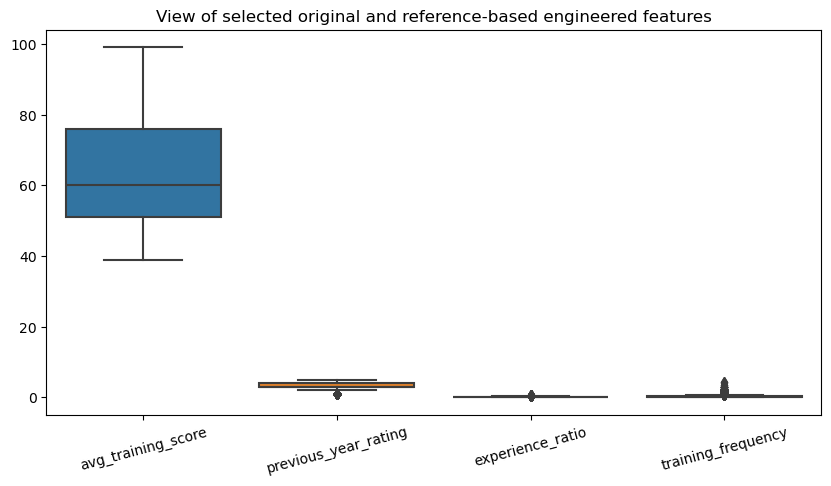

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['avg_training_score', 'previous_year_rating', 'experience_ratio', 'training_frequency']])
plt.title('View of selected original and reference-based engineered features')
plt.xticks(rotation=15)
plt.show()

## 3. Encoding

Drop `region` and `gender`, ordinal-encode `education`, and one-hot encode only the remaining nominal columns.


In [14]:
education_order = [["Below Secondary", "Bachelor's", "Master's & above"]]
education_encoder = OrdinalEncoder(categories=education_order, dtype=int)

target = df['is_promoted'].copy()

X = df.drop(columns=['employee_id', 'is_promoted', 'region', 'gender']).copy()
X['education'] = education_encoder.fit_transform(X[['education']]).astype(int).ravel()


gender_map = {'f': 0, 'm': 1, 'F': 0, 'M': 1}
X['gender'] = df['gender'].map(gender_map).fillna(-1).astype(int)

X[['gender']].head()

categorical_columns = ['department', 'recruitment_channel']
X = pd.get_dummies(X, columns=categorical_columns, drop_first=True, dtype=int)

X.shape


(54808, 23)

## 4. Feature review and export


In [15]:
y = target.copy()

mi_scores = pd.Series(mutual_info_classif(X, y, random_state=42), index=X.columns).sort_values(ascending=False)
mi_scores.head(15)

performance_score               0.038603
avg_training_score              0.031855
training_efficiency             0.027991
previous_year_rating            0.018465
awards_won?                     0.010750
gender                          0.008958
education                       0.007820
no_of_trainings                 0.006433
recruitment_channel_sourcing    0.005336
department_Sales & Marketing    0.002769
experience_ratio                0.002743
age                             0.002528
department_Legal                0.002280
department_Operations           0.001913
department_Technology           0.001784
dtype: float64

In [16]:
rf = RandomForestClassifier(n_estimators=250, random_state=42, class_weight='balanced_subsample')
rf.fit(X, y)

rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
rf_importance.head(15)

performance_score               0.145671
avg_training_score              0.120044
training_efficiency             0.108743
experience_ratio                0.105136
age                             0.089043
joining_age                     0.084082
training_frequency              0.055826
length_of_service               0.049735
previous_year_rating            0.048978
recruitment_channel_sourcing    0.029213
awards_won?                     0.027490
gender                          0.024384
department_Sales & Marketing    0.024365
education                       0.019559
department_Operations           0.016597
dtype: float64

In [17]:
top_features = pd.DataFrame({
    'mutual_info': mi_scores,
    'rf_importance': rf_importance
}).fillna(0)

top_features['combined_rank'] = top_features['mutual_info'].rank(ascending=False) + top_features['rf_importance'].rank(ascending=False)
top_features = top_features.sort_values('combined_rank')
top_features.head(20)

,mutual_info,rf_importance,combined_rank
performance_score,0.038603,0.145671,2.0
avg_training_score,0.031855,0.120044,4.0
training_efficiency,0.027991,0.108743,6.0
previous_year_rating,0.018465,0.048978,13.0
experience_ratio,0.002743,0.105136,15.0
awards_won?,0.010750,0.027490,16.0
age,0.002528,0.089043,17.0
gender,0.008958,0.024384,18.0
recruitment_channel_sourcing,0.005336,0.029213,19.0
education,0.007820,0.019559,21.0


In [18]:
selected_columns = top_features.head(20).index.tolist()

train_selected = pd.concat([X[selected_columns], y], axis=1)

train_selected.to_csv('Dataset/archive(2)/train_fe_alternative.csv', index=False)

train_selected.head()

,performance_score,avg_training_score,training_efficiency,previous_year_rating,experience_ratio,awards_won?,age,gender,recruitment_channel_sourcing,education,...,department_Sales & Marketing,length_of_service,no_of_trainings,training_frequency,department_Operations,department_Technology,department_Procurement,department_Legal,department_Finance,is_promoted
0,245.0,49,49.0,5.0,0.229,0,35,0,1,2,...,1,8,1,0.111,0,0,0,0,0,0
1,300.0,60,60.0,5.0,0.133,0,30,1,0,1,...,0,4,1,0.200,1,0,0,0,0,0
2,150.0,50,50.0,3.0,0.206,0,34,1,1,1,...,1,7,1,0.125,0,0,0,0,0,0
3,50.0,50,25.0,1.0,0.256,0,39,1,0,1,...,1,10,2,0.182,0,0,0,0,0,0
4,219.0,73,73.0,3.0,0.044,0,45,1,0,1,...,0,2,1,0.333,0,1,0,0,0,0


In [19]:
df.sample(5)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted,experience_ratio,joining_age,training_efficiency,training_frequency,performance_score
40214,36284,Sales & Marketing,region_13,Bachelor's,m,sourcing,1,31,4.0,6,0,51,0,0.194,25,51.0,0.143,204.0
37198,54114,Finance,region_2,Bachelor's,m,sourcing,1,27,3.0,1,0,56,0,0.037,26,56.0,0.500,168.0
298,58415,Sales & Marketing,region_7,Bachelor's,m,other,1,45,4.0,5,0,50,0,0.111,40,50.0,0.167,200.0
25690,70605,Sales & Marketing,region_2,Bachelor's,f,sourcing,1,40,4.0,5,0,46,0,0.125,35,46.0,0.167,184.0
39438,56296,Sales & Marketing,region_27,Bachelor's,f,other,1,29,3.0,1,0,50,0,0.034,28,50.0,0.500,150.0
